# 📊 Projeto Final – CF Tech
## Análise de Ações com Python

Este projeto tem como objetivo realizar uma análise exploratória dos dados históricos da ação **Itaú Unibanco (ITUB4)** listada na B3, com foco dinâmico nos últimos 12 meses. Aplicamos os conceitos de manipulação de dados com Pandas, cálculos estatísticos e matriciais com NumPy, além de visualizações avançadas com Matplotlib, Seaborn e mplfinance.

---

## 3.7 - Itaú (ITUB4)

### Conheça a empresa
O Itaú Unibanco é uma instituição financeira centenária que começou em 1924, quando João Moreira Salles fundou a Casa Moreira Salles em Poços de Caldas, Minas Gerais. Atualmente, é o maior banco brasileiro, oferecendo os mais diversos serviços bancários para pessoas físicas e pessoas jurídicas, como conta corrente, conta poupança, cartão de crédito, títulos de capitalização, consórcios, seguros, gestão de ativos, entre outros.

### Minha tese
O setor bancário demonstra alta resiliência histórica. O Itaú se destaca pela consistência na entrega de valor e forte liquidez de mercado. A tese baseia-se na identificação de pontos de entrada técnicos otimizados através do rastreamento de tendências de preços e volumes, aproveitando a volatilidade de curto prazo para capturar assimetrias favoráveis de retorno, maximizando o efeito dos juros compostos no longo prazo.

### Motivos para a recomendação de compra
* **Comportamento Direcional Consistente:** Identificação visual da estrutura de tendência primária do ativo através do histórico dinâmico de preços de fechamento (*Gráfico de Linha Spot*);
* **Forte Liquidez e Presença Institucional:** Confirmação de robusto volume financeiro transacionado diariamente, validado estatisticamente pelo cálculo da mediana e pela distribuição temporal das negociações (*Gráfico de Barras e Linha de Volume*);
* **Dinâmica de Acumulação e Distribuição:** Análise da correlação e do impacto do fluxo de volume sobre a formação dos preços de fechamento (*Gráfico de Dispersão Preço vs. Volume*);
* **Padrão de Volatilidade Controlada:** Mapeamento estatístico da distribuição de frequência dos retornos diários ($\text{dy}$), avaliando o comportamento das caudas e a dispersão dos retornos frente à densidade de probabilidade (*Histograma com Curva KDE*);
* **Momento Algorítmico de Compra:** Rastreamento de pontos de viragem e suportes dinâmicos de preço através do cruzamento estratégico de médias móveis (*Rastreador Algorítmico MMS 21 vs. MMS 50*);
* **Identificação de Zonas de Exaustão Técnica:** Mensuração do momento de mercado e força compradora/vendedora através de osciladores quantitativos estruturados em janelas móveis de 14 períodos (*Índice de Força Relativa - IFR / RSI*);
* **Sazonalidade de Retornos:** Avaliação matricial do desempenho composto mês a mês, permitindo identificar padrões temporais e comportamentos cíclicos de rentabilidade ao longo do ano fiscal (*Matriz Sazonal Heatmap*).

**Analista Responsável:** Jack Gregori Rodriguez Cachi  

🐂 Explicação do código abaixo:

* Importa as ferramentas essenciais para manipulação de dados (`pandas`, `numpy`), criação de gráficos (`matplotlib`, `seaborn`) e captura de dados financeiros (`yfinance`, `mplfinance`).
* Define o estilo visual dos gráficos como fundo branco quadriculado (`whitegrid`) para facilitar a leitura.
* Configura as dimensões padrão das imagens (`figsize`) e o tamanho das fontes dos títulos e eixos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import mplfinance as mpf

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13

🐂 Explicação do código abaixo:

* Faz o download automático de 1 ano de dados históricos da ação do Itaú (`ITUB4.SA`) direto do Yahoo Finance.
* Trata e simplifica a estrutura das colunas caso os cabeçalhos venham duplicados (`MultiIndex`).
* Realiza uma verificação rápida para garantir que não existem dados ausentes (nulos).
* Calcula a mediana do volume diário negociado e gera um sumário estatístico completo (médias, mínimos e máximos) para entender o comportamento das ações.

In [2]:
print("Descarregando dados historicos da ITUB4...")
ticker = "ITUB4.SA"

data = yf.download(ticker, period="1y")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

print("\n--- Verificacao de Dados Ausentes ---")
print(data.isnull().sum())

mediana_volume = data['Volume'].median()
print(f"\nA mediana do volume diário negociado para ITUB4 é: {mediana_volume:,.0f} ações.")

print("\n--- Sumário Estatístico Descritivo ---")
print(data.describe())

Descarregando dados historicos da ITUB4...


[*********************100%***********************]  1 of 1 completed


--- Verificacao de Dados Ausentes ---
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

A mediana do volume diário negociado para ITUB4 é: 22,343,948 ações.

--- Sumário Estatístico Descritivo ---
Price       Close        High         Low        Open        Volume
count  250.000000  250.000000  250.000000  250.000000  2.500000e+02
mean    38.083787   38.466203   37.725919   38.098839  2.509688e+07
std      4.819367    4.926004    4.716079    4.849727  1.065434e+07
min     30.944283   31.294394   30.657013   30.917352  7.190900e+06
25%     33.914917   34.225354   33.679909   33.890248  1.776719e+07
50%     37.459126   37.705685   37.110985   37.455725  2.234395e+07
75%     42.131955   42.777132   41.869467   42.205778  3.217697e+07
max     48.883183   49.180224   48.120775   48.566339  8.033440e+07


*Gráfico de linha do preço de fechamento* 🐂

Explicação do código abaixo: 
- Cria um gráfico de linha (`plt.plot`) com o preço de fechamento ao longo do tempo.
- Permite visualizar a tendência primária do ativo e identificar topos e fundos no período.

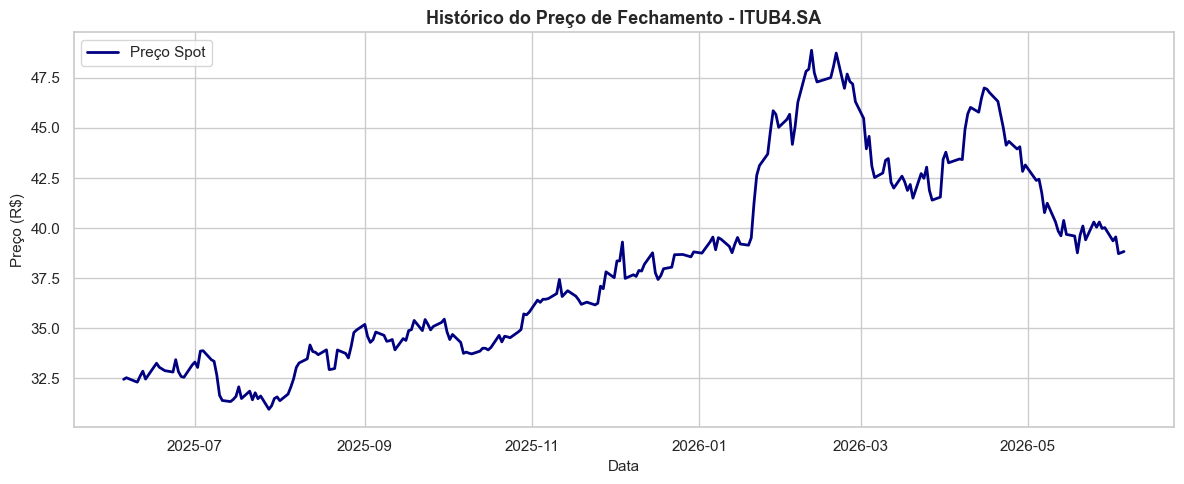

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data['Close'], color='navy', linewidth=2, label='Preço Spot')
plt.title(f'Histórico do Preço de Fechamento - {ticker}', fontsize=13, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

A linha do preço revela a direção predominante do ITUB4 nos últimos 12 meses. Altas consistentes com poucos recuos indicam tendência primária de alta.

*Gráfico de volume de negociações* 🐂

Explicação do código abaixo:
- Cria um gráfico de linha com o volume diário negociado.
- Picos de volume muito acima do padrão podem sinalizar eventos corporativos relevantes, como divulgação de resultados ou pagamento de proventos.

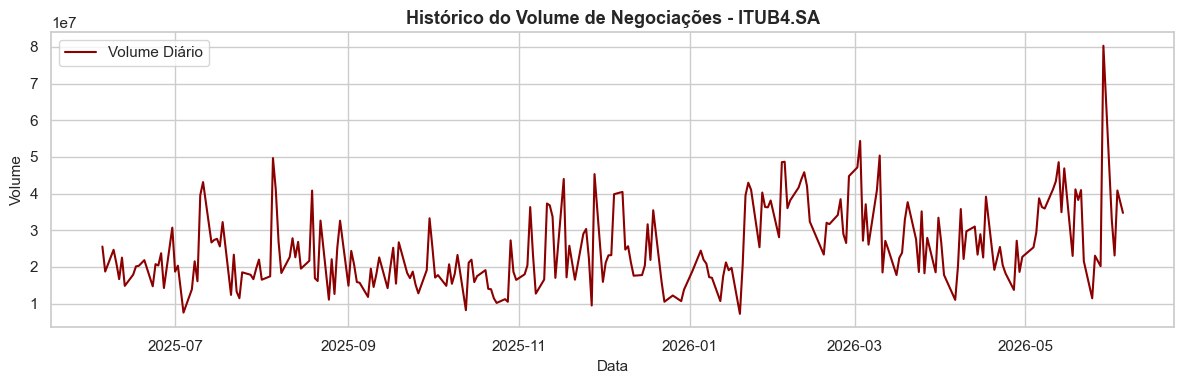

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data['Volume'], color='darkred', linewidth=1.5, label='Volume Diário')
plt.title(f'Histórico do Volume de Negociações - {ticker}', fontsize=13, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

O volume é o indicador de liquidez e interesse do mercado. Dias com volume muito acima da média merecem atenção especial — geralmente coincidem com notícias relevantes sobre a empresa ou o setor bancário.

*Gráfico de barras do volume diário* 🐂

Explicação do código abaixo:
- Cria um gráfico de barras (`plt.bar`) com o volume de cada pregão de forma independente.
- Facilita a identificação visual de dias com participação fora do padrão em relação ao volume mediano.

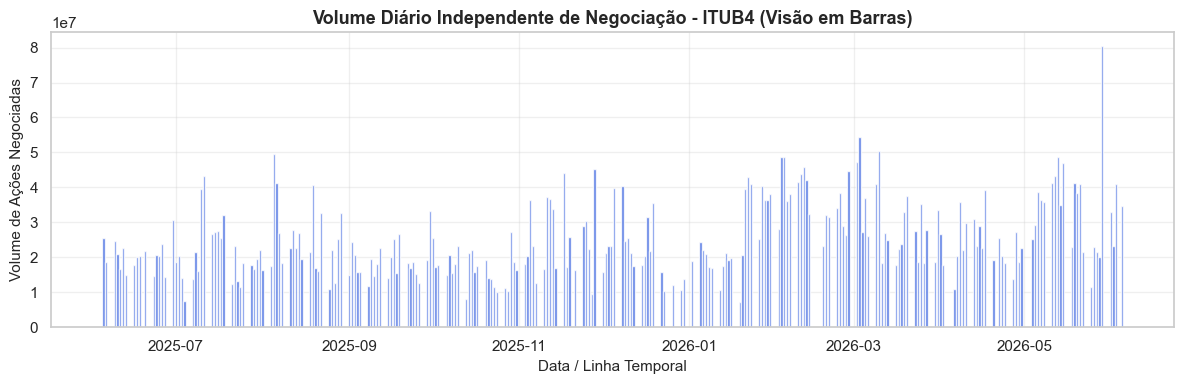

In [12]:
plt.figure(figsize=(12, 4))
plt.bar(data.index, data['Volume'], color='royalblue', alpha=0.8, width=0.8)
plt.title('Volume Diário Independente de Negociação - ITUB4 (Visão em Barras)', fontsize=13, fontweight='bold')
plt.xlabel('Data / Linha Temporal')
plt.ylabel('Volume de Ações Negociadas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A visão em barras complementa o gráfico de linha: enquanto a linha mostra a tendência geral do volume, as barras destacam individualmente os pregões de maior e menor movimentação.

*Gráfico de dispersão — Preço vs. Volume* 🐂

Explicação do código abaixo:
- Cria um gráfico de dispersão (`sns.scatterplot`) relacionando volume de negociações com o preço de fechamento.
- Cada ponto representa um pregão. Usado para identificar correlação entre preço e volume.

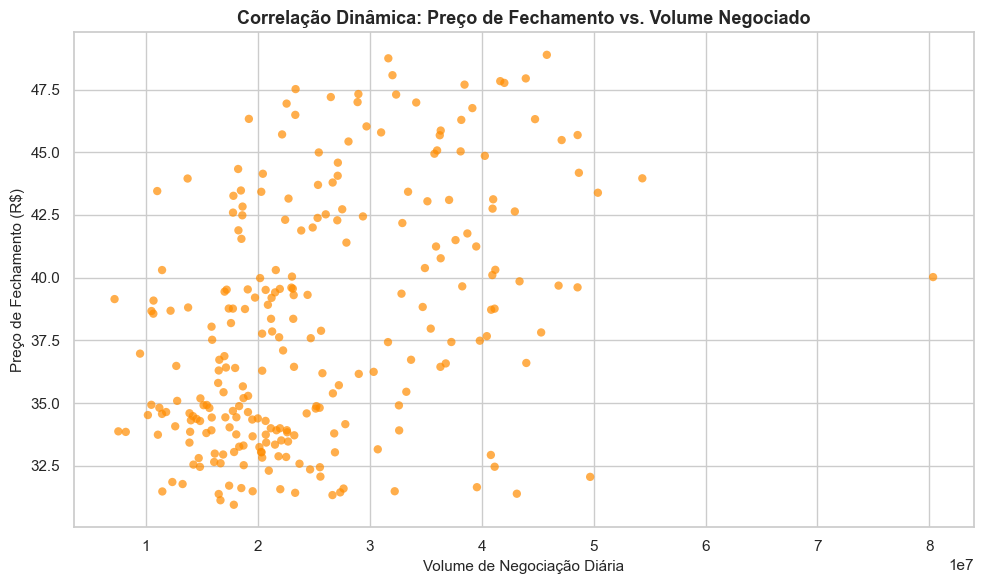

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Volume', y='Close', color='darkorange', alpha=0.7, edgecolor='none')
plt.title('Correlação Dinâmica: Preço de Fechamento vs. Volume Negociado', fontsize=13, fontweight='bold')
plt.xlabel('Volume de Negociação Diária')
plt.ylabel('Preço de Fechamento (R$)')
plt.tight_layout()
plt.show()

A dispersão dos pontos sugere que não há uma correlação linear forte entre preço e volume.
Os pontos isolados à direita representam dias de negociação atípicos, possivelmente relacionados a eventos importantes da empresa.
A concentração de pontos indica que o ITUB4 tem comportamento relativamente estável em termos de preço e volume na maior parte do tempo.

*Histograma de retornos diários* 🐂

Explicação do código abaixo:
- Calcula o retorno diário percentual com `pct_change()`.
- Plota o histograma com a curva de densidade KDE (`kde=True`) usando `sns.histplot`.
- Permite avaliar a distribuição dos retornos: simetria, frequência de dias positivos e intensidade dos movimentos extremos.

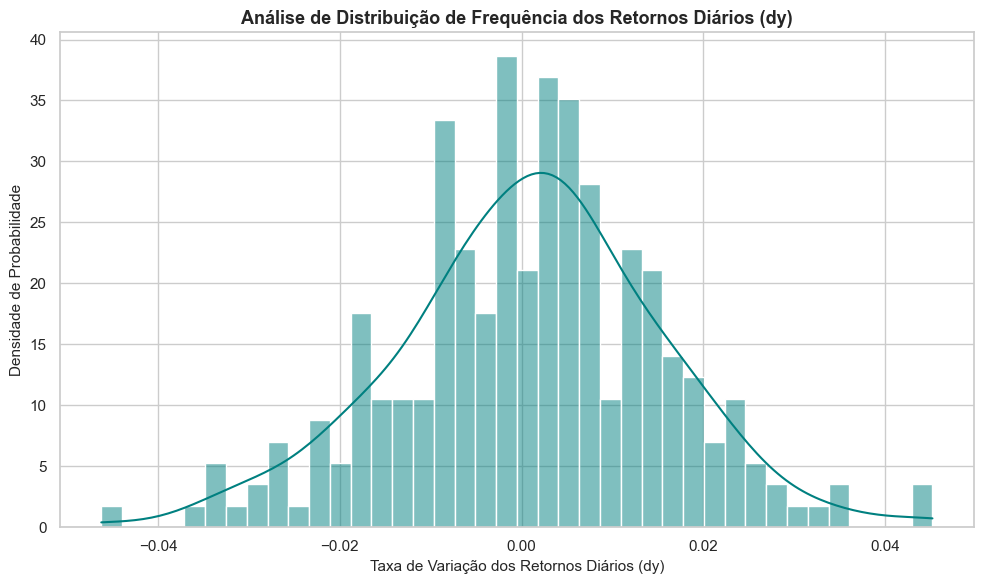

In [14]:
dy = data['Close'].pct_change().dropna()

plt.figure(figsize=(10, 6))
sns.histplot(dy, kde=True, color='teal', bins=40, stat='density')
plt.title('Análise de Distribuição de Frequência dos Retornos Diários (dy)', fontsize=13, fontweight='bold')
plt.xlabel('Taxa de Variação dos Retornos Diários (dy)')
plt.ylabel('Densidade de Probabilidade')
plt.tight_layout()
plt.show()

Esse histograma fornece uma representação visual da frequência com que diferentes níveis de retorno ocorrem. Se a distribuição estiver centrada à direita de zero, o ativo apresentou mais dias positivos do que negativos no período.

*Rastreador de tendência — Médias Móveis (MMS 21 e MMS 50)* 🐂

Explicação do código abaixo:
- Calcula médias móveis com `.rolling(janela).mean()`:
  - **MMS 21:** média dos últimos 21 fechamentos — reflete o comportamento de curto prazo.
  - **MMS 50:** média dos últimos 50 fechamentos — reflete o comportamento de médio prazo.
- O condicional `if/else` ao final identifica automaticamente o sinal técnico vigente.

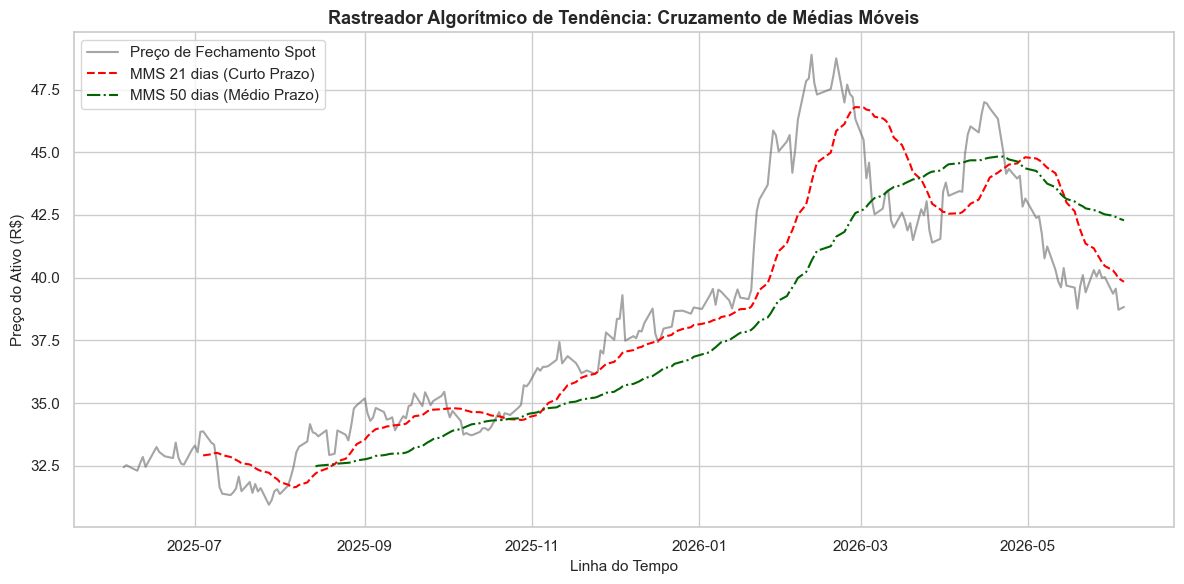

DIAGNÓSTICO TÉCNICO CONDICIONAL DA TENDÊNCIA ATUAL
SINAL VIGENTE: ALINHAMENTO BAIXISTA (Death Cross) | MMS21 (39.83) <= MMS50 (42.28)


In [15]:
data['MMS_21'] = data['Close'].rolling(window=21).mean()
data['MMS_50'] = data['Close'].rolling(window=50).mean()

plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Preço de Fechamento Spot', color='dimgray', alpha=0.6, lw=1.5)
plt.plot(data['MMS_21'], label='MMS 21 dias (Curto Prazo)', color='red', linestyle='--')
plt.plot(data['MMS_50'], label='MMS 50 dias (Médio Prazo)', color='darkgreen', linestyle='-.')
plt.title('Rastreador Algorítmico de Tendência: Cruzamento de Médias Móveis', fontsize=13, fontweight='bold')
plt.xlabel('Linha do Tempo')
plt.ylabel('Preço do Ativo (R$)')
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

ultima_mms21 = float(data['MMS_21'].iloc[-1])
ultima_mms50 = float(data['MMS_50'].iloc[-1])

print("DIAGNÓSTICO TÉCNICO CONDICIONAL DA TENDÊNCIA ATUAL")
if ultima_mms21 > ultima_mms50:
    print(f"SINAL VIGENTE: ALINHAMENTO AUTISTA (Golden Cross) | MMS21 ({ultima_mms21:.2f}) > MMS50 ({ultima_mms50:.2f})")
else:
    print(f"SINAL VIGENTE: ALINHAMENTO BAIXISTA (Death Cross) | MMS21 ({ultima_mms21:.2f}) <= MMS50 ({ultima_mms50:.2f})")

-Quando a MMS 21 cruza acima da MMS 50, geralmente é interpretado como um sinal de tendência de alta (Golden Cross).

-O inverso, quando a MMS 21 cruza abaixo da MMS 50, pode indicar uma tendência de baixa (Death Cross).

-O espaço entre as duas médias é chamado de "área de valor" — útil para identificar oportunidades de entrada na direção da tendência.

*Microestrutura de preços — Candlestick - conteúdo Extra* 🐂

Explicação do código abaixo:
- Utiliza a biblioteca `mplfinance` para plotar o gráfico de candlestick dos últimos 60 pregões.
- Cada vela contém quatro informações: abertura, máxima, mínima e fechamento.
- Velas verdes indicam dia de alta; velas vermelhas indicam dia de baixa.
- O painel de volume é exibido automaticamente com `volume=True`.

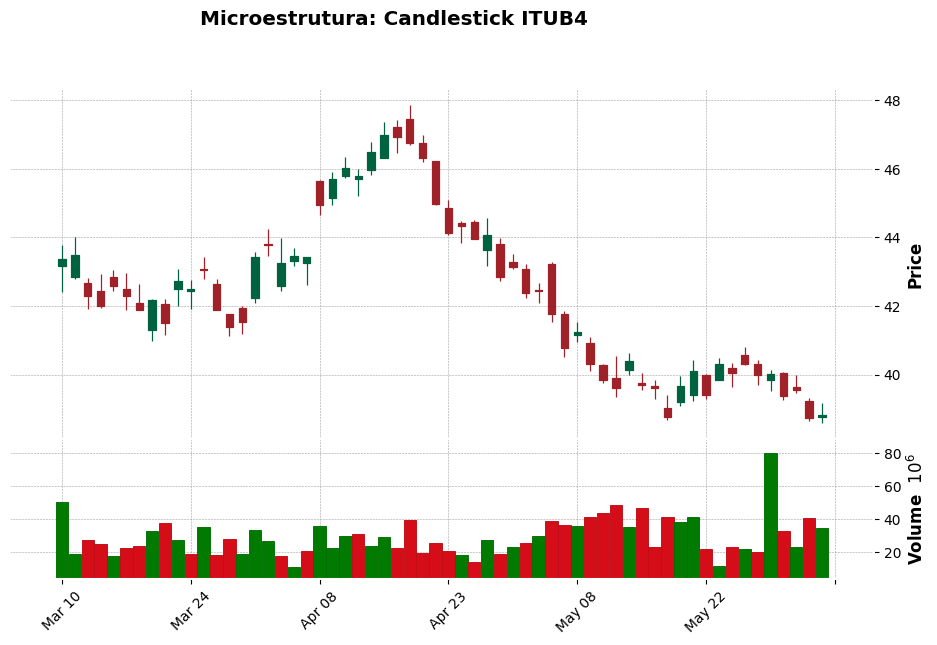

In [16]:
data_mpf = data.tail(60).copy()
mpf.plot(data_mpf, type='candle', style='charles', title='Microestrutura: Candlestick ITUB4', volume=True, figsize=(12, 7))

O candlestick é o gráfico padrão da análise técnica profissional. Permite identificar padrões de reversão e continuidade de tendência que não são visíveis em um simples gráfico de linha.

*Oscilador de momento — IFR / RSI (14 períodos) - Conteúdo Extra* 🐂


Explicação do código abaixo:
- Calcula o Índice de Força Relativa (IFR) de 14 períodos usando `diff()`, `clip()` e `ewm()`.
- O IFR oscila entre 0 e 100:
  - **Acima de 70:** sobrecompra — possível reversão de baixa.
  - **Abaixo de 30:** sobrevenda — possível reversão de alta.
  - **Entre 30 e 70:** zona neutra de equilíbrio.

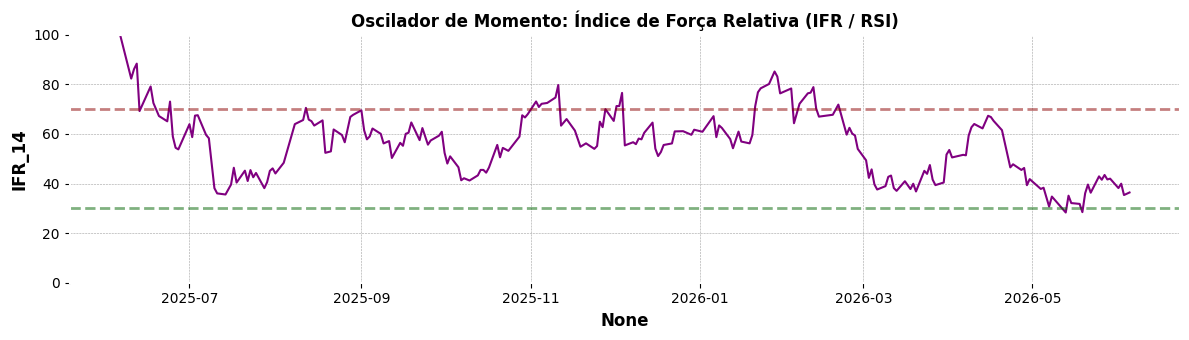

In [17]:
variacao_preco = data['Close'].diff()
ganhos_diarios = variacao_preco.clip(lower=0)
perdas_diarias = -1 * variacao_preco.clip(upper=0)
media_ganhos_exp = ganhos_diarios.ewm(com=13, adjust=False).mean()
media_perdas_exp = perdas_diarias.ewm(com=13, adjust=False).mean()
data['IFR_14'] = 100 - (100 / (1 + (media_ganhos_exp / media_perdas_exp)))

plt.figure(figsize=(12, 3.5))
sns.lineplot(data=data, x=data.index, y='IFR_14', color='purple', linewidth=1.5)
plt.axhline(70, color='darkred', linestyle='--', alpha=0.5)
plt.axhline(30, color='darkgreen', linestyle='--', alpha=0.5)
plt.title('Oscilador de Momento: Índice de Força Relativa (IFR / RSI)', fontsize=12, fontweight='bold')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

O RSI quantifica o momentum do mercado e delimita as zonas de maior risco e as janelas de possível entrada. Deve ser analisado em conjunto com os demais indicadores — nunca de forma isolada.

*Matriz sazonal de retornos mensais - Conteúdo Extra* 🐂

Explicação do código abaixo:
- Calcula o retorno composto mensal agrupando os retornos diários por ano e mês com `groupby()`.
- Reorganiza os dados em uma tabela ano × mês com `.unstack()`.
- Plota o heatmap com `sns.heatmap()` usando a paleta verde (positivo) e vermelho (negativo).

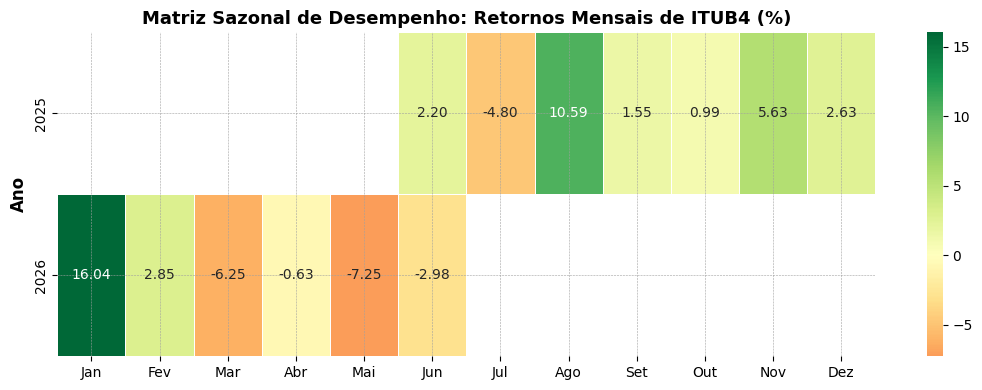

In [18]:
df_sazonal = data[['Close']].copy()
df_sazonal['Retorno_Diario'] = df_sazonal['Close'].pct_change()
df_sazonal['Ano'] = df_sazonal.index.year
df_sazonal['Mes'] = df_sazonal.index.month
matriz_retornos_mensais = df_sazonal.groupby(['Ano', 'Mes'])['Retorno_Diario'].apply(lambda x: (1 + x).prod() - 1).unstack() * 100
matriz_retornos_mensais.columns = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'][:len(matriz_retornos_mensais.columns)]

plt.figure(figsize=(11, 4))
sns.heatmap(matriz_retornos_mensais, annot=True, fmt=".2f", cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Matriz Sazonal de Desempenho: Retornos Mensais de ITUB4 (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

O heatmap expõe padrões sazonais históricos do ITUB4. Meses consistentemente verdes ao longo dos anos indicam sazonalidade positiva; meses consistentemente vermelhos indicam sazonalidade negativa.

### Conclusão ✈️

- Esta conclusão vai além dos gráficos produzidos neste projeto.

- Alguns dos dados apresentados abaixo foram obtidos por pesquisa independente em fontes públicas como o status Invest, Genial Investimentos e relatórios oficiais do Itaú com o objetivo de enriquecer a análise.

- A análise técnica do ITUB4 nos últimos 12 meses reforça a tese fundamentalista já construída: O ativo apresenta comportamento direcional rastreável, liquidez institucional consistente e padrões técnicos favoráveis ao posicionamento comprador.

- O cruzamento das médias móveis, o comportamento do RSI e a estrutura dos candlesticks apontam para um ativo que, mesmo diante de volatilidade pontual, mantém integridade técnica de tendência.

- Os picos de volume identificados coincidem com momentos de forte entrada compradora no ativo, grandes investidores institucionais aumentando posição, o que pressiona o preço para cima e reforça a direção da tendência de alta.

- O momento atual do ativo reforça a tese: nos últimos 5 anos o ITUB4 saiu de R$ 14,00 e chegou a bater R$ 48,99 na máxima recente com valorização superior a 250% no período. A cotação atual de R$ 38,83, após acomodação, representa um ponto de entrada tecnicamente interessante

- Riscos existem que devem ser monitorados de perto como por exemplo o aumento de inadimplência em ambiente de juros elevados, pressão sobre spreads e cenário macro desafiador em 2026. Ainda assim, a disciplina de gestão ao longo de múltiplos ciclos de crédito, a previsibilidade dos resultados dentro do guidance, faz eu acreditar no ativo.

**Recomendação: COMPRA** para carteiras que buscam renda passiva crescente, geração de valor composto via reinvestimento de proventos e exposição a um dos bancos mais rentáveis da América Latina, com múltiplos ainda atrativos e upside relevante no horizonte de 12 meses.

**Analista Responsável:** Jack Gregori Rodriguez Cachi